###### 131_2_practical_extract_part_code.ipynb

In [2]:
import pandas as pd
import re
import matplotlib.pyplot as plt

In [3]:
pd.set_option("display.max_columns", None)
plt.rcParams["font.family"] = "Meiryo"

In [4]:
df_defect = pd.read_csv("dataset/defect_comment.csv")
df_defect

,site,model,defect_id,comment
0,SUS,J69P,D-001,2026/06/01にKLAK-67890で1件発生。160V条件で確認。
1,SUS,J69P,D-002,2026/06/03にKLAK-67890とLCM-220を確認。再発の可能性あり。
2,SUS,J69P,D-003,Buck-IC周辺を確認。KLBC-12345で焼損痕あり。
3,WSE,310D,D-004,2026/06/04にLCM-220で2件発生。140V検査では検出せず。
4,WSE,310D,D-005,温度85C条件でCAN-330の1件を確認。
5,GSE,J69P,D-006,2026/06/05にCAN-330で1件再発。12V条件で確認。
6,GSE,J69P,D-007,CAN-330とKLAK-67890を同時に確認。
7,MELMB,310D,D-008,現象再現せず。対象品番KLEE-55555は継続確認中。
8,MELMB,310D,D-009,PY-110相当品で1件確認。160V条件で確認。
9,MELMB,310D,D-010,コメントのみ。対象品番の記載なし。


In [5]:
#cell3から
selected_df = df_defect.set_index("defect_id")["comment"].str.extractall(
    r"([A-Z]{2,}-\d{3,})",
    flags=re.IGNORECASE,
)
selected_df


0
defect_id match            
D-001     0      KLAK-67890
D-002     0      KLAK-67890
          1         LCM-220
D-003     0      KLBC-12345
D-004     0         LCM-220
D-005     0         CAN-330
D-006     0         CAN-330
D-007     0         CAN-330
          1      KLAK-67890
D-008     0      KLEE-55555
D-009     0          PY-110

In [6]:
selected_df = selected_df.rename(
    columns={
        0: "part_code",
    }
)
selected_df

part_code
defect_id match            
D-001     0      KLAK-67890
D-002     0      KLAK-67890
          1         LCM-220
D-003     0      KLBC-12345
D-004     0         LCM-220
D-005     0         CAN-330
D-006     0         CAN-330
D-007     0         CAN-330
          1      KLAK-67890
D-008     0      KLEE-55555
D-009     0          PY-110

In [7]:
df_parts = selected_df.reset_index()
df_parts

,defect_id,match,part_code
0,D-001,0,KLAK-67890
1,D-002,0,KLAK-67890
2,D-002,1,LCM-220
3,D-003,0,KLBC-12345
4,D-004,0,LCM-220
5,D-005,0,CAN-330
6,D-006,0,CAN-330
7,D-007,0,CAN-330
8,D-007,1,KLAK-67890
9,D-008,0,KLEE-55555


In [8]:
#cell6
df_base = df_defect[
    [
        "defect_id",
        "site",
        "model",
        "comment",
    ]
].copy()
df_base

,defect_id,site,model,comment
0,D-001,SUS,J69P,2026/06/01にKLAK-67890で1件発生。160V条件で確認。
1,D-002,SUS,J69P,2026/06/03にKLAK-67890とLCM-220を確認。再発の可能性あり。
2,D-003,SUS,J69P,Buck-IC周辺を確認。KLBC-12345で焼損痕あり。
3,D-004,WSE,310D,2026/06/04にLCM-220で2件発生。140V検査では検出せず。
4,D-005,WSE,310D,温度85C条件でCAN-330の1件を確認。
5,D-006,GSE,J69P,2026/06/05にCAN-330で1件再発。12V条件で確認。
6,D-007,GSE,J69P,CAN-330とKLAK-67890を同時に確認。
7,D-008,MELMB,310D,現象再現せず。対象品番KLEE-55555は継続確認中。
8,D-009,MELMB,310D,PY-110相当品で1件確認。160V条件で確認。
9,D-010,MELMB,310D,コメントのみ。対象品番の記載なし。


In [9]:
#cell7

df_parts_detail = pd.merge(
    df_parts,
    df_base,
    on="defect_id",
    how="left",
)
df_parts_detail

,defect_id,match,part_code,site,model,comment
0,D-001,0,KLAK-67890,SUS,J69P,2026/06/01にKLAK-67890で1件発生。160V条件で確認。
1,D-002,0,KLAK-67890,SUS,J69P,2026/06/03にKLAK-67890とLCM-220を確認。再発の可能性あり。
2,D-002,1,LCM-220,SUS,J69P,2026/06/03にKLAK-67890とLCM-220を確認。再発の可能性あり。
3,D-003,0,KLBC-12345,SUS,J69P,Buck-IC周辺を確認。KLBC-12345で焼損痕あり。
4,D-004,0,LCM-220,WSE,310D,2026/06/04にLCM-220で2件発生。140V検査では検出せず。
5,D-005,0,CAN-330,WSE,310D,温度85C条件でCAN-330の1件を確認。
6,D-006,0,CAN-330,GSE,J69P,2026/06/05にCAN-330で1件再発。12V条件で確認。
7,D-007,0,CAN-330,GSE,J69P,CAN-330とKLAK-67890を同時に確認。
8,D-007,1,KLAK-67890,GSE,J69P,CAN-330とKLAK-67890を同時に確認。
9,D-008,0,KLEE-55555,MELMB,310D,現象再現せず。対象品番KLEE-55555は継続確認中。


In [10]:
#cell8

df_part_summary = df_parts_detail.groupby(
    [
        "site",
        "part_code",
    ],
    as_index=False,
)["defect_id"].count()

df_part_summary

,site,part_code,defect_id
0,GSE,CAN-330,2
1,GSE,KLAK-67890,1
2,MELMB,KLEE-55555,1
3,MELMB,PY-110,1
4,SUS,KLAK-67890,2
5,SUS,KLBC-12345,1
6,SUS,LCM-220,1
7,WSE,CAN-330,1
8,WSE,LCM-220,1


In [11]:
#cell9
df_part_summary = df_part_summary.rename(
    columns={
        "defect_id": "count",
    }
)

df_part_summary = df_part_summary.sort_values(
    "count",
    ascending=False,
).reset_index(drop=True)

df_part_summary

,site,part_code,count
0,GSE,CAN-330,2
1,SUS,KLAK-67890,2
2,GSE,KLAK-67890,1
3,MELMB,KLEE-55555,1
4,MELMB,PY-110,1
5,SUS,KLBC-12345,1
6,SUS,LCM-220,1
7,WSE,CAN-330,1
8,WSE,LCM-220,1


In [ ]:
#cell10
extracted_defect_ids = df_parts_detail["defect_id"].unique()
extracted_defect_ids

array(['D-001', 'D-002', 'D-003', 'D-004', 'D-005', 'D-006', 'D-007',
       'D-008', 'D-009'], dtype=object)

In [14]:
#cell11
df_no_part = df_defect[
    ~df_defect["defect_id"].isin(extracted_defect_ids)
].copy()
df_no_part

,site,model,defect_id,comment
9,MELMB,310D,D-010,コメントのみ。対象品番の記載なし。


In [17]:
#cell12
df_site_count = df_parts_detail.groupby(
    "site",
    as_index=False,
)["part_code"].count()

df_site_count = df_site_count.rename(
    columns={
        "part_code": "count",
    }
)

df_site_count = df_site_count.sort_values(
    "count",
    ascending=False,
).reset_index(drop=True)

df_site_count

,site,count
0,SUS,4
1,GSE,3
2,MELMB,2
3,WSE,2


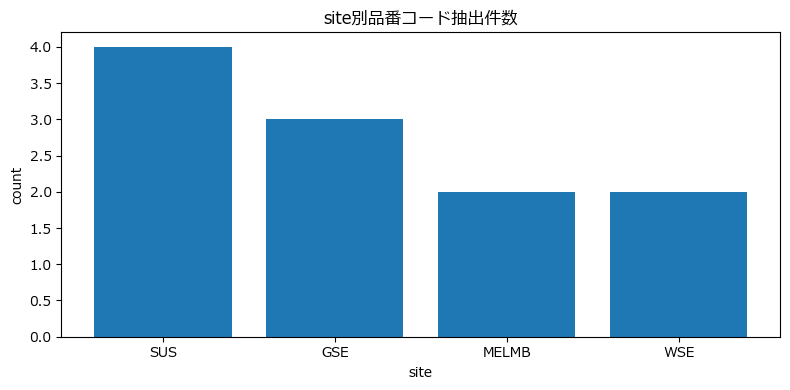

In [22]:
#cell13
plt.figure(figsize=(8, 4))

plt.bar(
    df_site_count["site"],
    df_site_count["count"],
)

plt.title("site別品番コード抽出件数")
plt.xlabel("site")
plt.ylabel("count")

plt.tight_layout()
plt.show()